![jupyter](img/logoItq.png)

**Nombre:** *Jair Patiño*

![jupyter](img/logoPy.png)

In [16]:
# Descarga de datos
import kagglehub

# Manipulación y visualización
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from math import sqrt

# Machine Learning (Scikit-Learn)
from sklearn import metrics
from sklearn import preprocessing
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import f_regression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.feature_selection import VarianceThreshold, f_regression, mutual_info_regression
from sklearn.model_selection import train_test_split
from sklearn import preprocessing, linear_model, metrics
from sklearn.model_selection import KFold, cross_validate
from sklearn.metrics import make_scorer

## 1.	Carga y comprensión de los datos 

In [31]:
path = kagglehub.dataset_download("mirichoi0218/insurance")
df = pd.read_csv(path + "/insurance.csv")

print("Dimensiones del dataset:", df.shape)
display(df.head())

Dimensiones del dataset: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 2.	EDA y calidad de los datos 

In [18]:
print("Valores ausentes por columna:")
display(df.isnull().sum().to_frame("nulos"))
print("Filas duplicadas:", df.duplicated().sum())

# Imputación de ausentes con la media (Programa 4), solo si existieran
cols_numericas = ["age", "bmi", "children", "charges"]
if df[cols_numericas].isnull().sum().sum() > 0:
    imputer = SimpleImputer(strategy="mean")
    df[cols_numericas] = imputer.fit_transform(df[cols_numericas])
else:
    print("No hay valores ausentes: no se requiere imputación.")

# Se elimina el duplicado exacto para no sesgar el modelo
df = df.drop_duplicates().reset_index(drop=True)
print("Filas tras eliminar duplicados:", len(df))

Valores ausentes por columna:


,nulos
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


Filas duplicadas: 1
No hay valores ausentes: no se requiere imputación.
Filas tras eliminar duplicados: 1337


In [19]:
print("Asimetría (skew) de charges:", round(df["charges"].skew(), 3))

df_corr = df.copy()
df_corr["sex"] = (df_corr["sex"] == "male").astype(int)
df_corr["smoker"] = (df_corr["smoker"] == "yes").astype(int)
df_corr[["age", "sex", "bmi", "children", "smoker", "charges"]].corr().round(3)

Asimetría (skew) de charges: 1.515


,age,sex,bmi,children,smoker,charges
age,1.000,-0.020,0.109,0.042,-0.026,0.298
sex,-0.020,1.000,0.046,0.018,0.077,0.058
bmi,0.109,0.046,1.000,0.013,0.004,0.198
children,0.042,0.018,0.013,1.000,0.007,0.067
smoker,-0.026,0.077,0.004,0.007,1.000,0.787
charges,0.298,0.058,0.198,0.067,0.787,1.000


## 3.	Detección de outliers

In [20]:
df_if = df[["age", "bmi", "children", "charges"]].copy()
df_if["smoker"] = (df["smoker"] == "yes").astype(int)

def find_outliers(df, algorithm):
    outlier_method = algorithm.fit(df)
    df_outliers = outlier_method.predict(df)
    pos_outliers = np.where(df_outliers == -1)[0]
    print("Número de outliers:", len(pos_outliers))
    return df_outliers, pos_outliers

IF = IsolationForest(max_samples="auto", contamination=0.05, random_state=42)
df_outliers, pos_outliers = find_outliers(df_if, IF)

Número de outliers: 67


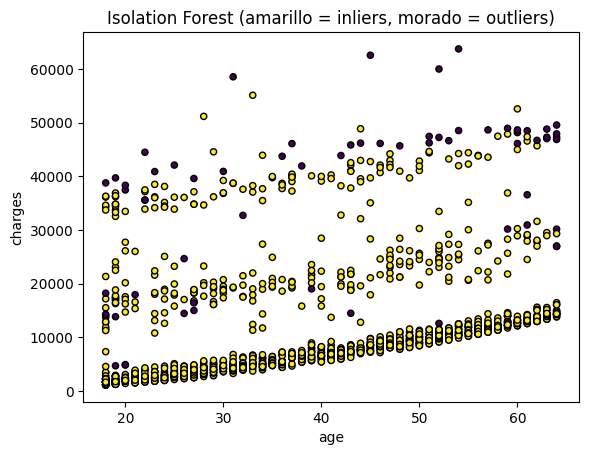

In [21]:
plt.scatter(df["age"], df["charges"], c=df_outliers, s=20, edgecolor="k")
plt.xlabel("age")
plt.ylabel("charges")
plt.title("Isolation Forest (amarillo = inliers, morado = outliers)")
plt.show()

In [22]:
# Eliminamos los outliers
df_clean = df[df_outliers == 1].reset_index(drop=True)
print(f"Dataset original: {len(df)} filas → sin outliers: {len(df_clean)} filas")

Dataset original: 1337 filas → sin outliers: 1270 filas


## 4.	Preparación de variables 

In [23]:
df_prep = pd.get_dummies(df_clean, columns=["sex", "smoker", "region"], drop_first=True, dtype=float)
df_prep.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,0.0,1.0,0.0,0.0,1.0
1,18,33.770,1,1725.55230,1.0,0.0,0.0,1.0,0.0
2,28,33.000,3,4449.46200,1.0,0.0,0.0,1.0,0.0
3,33,22.705,0,21984.47061,1.0,0.0,1.0,0.0,0.0
4,32,28.880,0,3866.85520,1.0,0.0,1.0,0.0,0.0


## 5.	Normalización o estandarización 

In [24]:
cols_num = ["age", "bmi", "children"]

normalizer = preprocessing.MinMaxScaler()
df_norm = pd.DataFrame(normalizer.fit_transform(df_prep[cols_num]), columns=cols_num)

standardizer_demo = preprocessing.StandardScaler()
df_std = pd.DataFrame(standardizer_demo.fit_transform(df_prep[cols_num]), columns=cols_num)

print("Normalizado:"); display(df_norm.describe().loc[["min", "max"]].round(3))
print("Estandarizado:"); display(df_std.describe().loc[["mean", "std"]].round(3))

Normalizado:


,age,bmi,children
min,0.0,0.0,0.0
max,1.0,1.0,1.0


Estandarizado:


,age,bmi,children
mean,-0.0,-0.0,0.0
std,1.0,1.0,1.0


## 6.	Selección de atributos 

In [25]:
atributos = [c for c in df_prep.columns if c != "charges"]
X_all = df_prep[atributos]
y_all = df_prep["charges"]

# VarianceThreshold
X_all_norm = preprocessing.MinMaxScaler().fit_transform(X_all)
sel = VarianceThreshold(0.01).fit(X_all_norm)

# F-test e información mutua (normalizados)
f_test, _ = f_regression(X_all, y_all)
f_test = f_test / np.max(f_test)
mi = mutual_info_regression(X_all, y_all, random_state=42)
mi = mi / np.max(mi)

ranking = pd.DataFrame({"Varianza OK": sel.get_support(), "F-test": f_test, "Info. mutua": mi}, index=atributos)
display(ranking.sort_values("F-test", ascending=False).round(3))

umbral = 0.1
seleccionados = ranking[ranking["Varianza OK"] & ((ranking["F-test"] >= umbral) | (ranking["Info. mutua"] >= umbral))].index.tolist()
print("Atributos seleccionados:", seleccionados)

,Varianza OK,F-test,Info. mutua
smoker_yes,True,1.000,0.211
age,True,0.067,1.000
bmi,True,0.009,0.045
sex_male,True,0.002,0.119
region_southwest,True,0.001,0.002
region_southeast,True,0.001,0.020
children,True,0.000,0.105
region_northwest,True,0.000,0.035


Atributos seleccionados: ['age', 'children', 'sex_male', 'smoker_yes']


## 7.	Validación de datos 

In [26]:
X = df_prep[seleccionados]
y = df_prep["charges"]

X_training, X_testing, y_training, y_testing = train_test_split(X, y, test_size=0.2, random_state=42)
print("Entrenamiento:", X_training.shape, "| Prueba:", X_testing.shape)

Entrenamiento: (1016, 4) | Prueba: (254, 4)


## 8.	Entrenamiento mediante Regresión Lineal 

In [27]:
# Estandarización de los datos de entrenamiento
standardizer = preprocessing.StandardScaler()
stdr_trained = standardizer.fit(X_training)
X_stdr = stdr_trained.transform(X_training)

# Construcción del algoritmo de aprendizaje
reg = linear_model.LinearRegression(fit_intercept=True)

# Métricas de evaluación
metricas = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": make_scorer(lambda y, y_pred: sqrt(metrics.mean_squared_error(y, y_pred)), greater_is_better=False),
    "MAPE": make_scorer(lambda y, y_pred: np.mean(np.abs((y - y_pred) / y)) * 100, greater_is_better=False),
    "R2": "r2",
}

# Validación cruzada interna
cross_val_results = cross_validate(reg, X_stdr, y_training,
                                   cv=KFold(n_splits=5, shuffle=True, random_state=42), scoring=metricas)
cv_df = pd.DataFrame({"MAE": -cross_val_results["test_MAE"], "RMSE": -cross_val_results["test_RMSE"],
                      "MAPE (%)": -cross_val_results["test_MAPE"], "R2": cross_val_results["test_R2"]})
cv_df.loc["promedio"] = cv_df.mean()
cv_df.round(3)

,MAE,RMSE,MAPE (%),R2
0,3559.703,5485.623,33.555,0.746
1,3971.524,6330.155,34.111,0.597
2,3426.945,5484.728,35.859,0.715
3,3250.195,5359.248,30.822,0.750
4,3804.800,6008.131,31.387,0.678
promedio,3602.633,5733.577,33.147,0.697


In [28]:
# Entrenamiento con todos los datos de entrenamiento para obtener los coeficientes del modelo
model = reg.fit(X_stdr, y_training)

print("Término independiente:", round(model.intercept_, 4))
pd.Series(model.coef_, index=seleccionados).round(4).to_frame("coeficiente")

Término independiente: 12002.7325


,coeficiente
age,3597.7638
children,280.1715
sex_male,103.1392
smoker_yes,8299.4104


## 9.	Evaluación

In [29]:
X_test_stdr = stdr_trained.transform(X_testing)
y_pred_test = model.predict(X_test_stdr)

MAE = metrics.mean_absolute_error(y_testing, y_pred_test)
MSE = metrics.mean_squared_error(y_testing, y_pred_test)
RMSE = sqrt(MSE)
MAPE = metrics.mean_absolute_percentage_error(y_testing, y_pred_test) * 100
R2 = metrics.r2_score(y_testing, y_pred_test)

print("MAE:  %.4f" % MAE)
print("MSE:  %.4f" % MSE)
print("RMSE: %.4f" % RMSE)
print("MAPE: %.4f %%" % MAPE)
print("R2:   %.4f" % R2)

MAE:  3880.5889
MSE:  39607991.6905
RMSE: 6293.4880
MAPE: 32.6282 %
R2:   0.6870


## 10.	Predicción con nuevos datos 

In [30]:
nuevos = pd.DataFrame({
    "age":      [25, 45, 60],
    "sex":      ["female", "male", "male"],
    "bmi":      [22.5, 33.0, 38.2],
    "children": [0, 2, 3],
    "smoker":   ["no", "no", "yes"],
    "region":   ["southwest", "northeast", "southeast"],
})

nuevos_prep = pd.get_dummies(nuevos, columns=["sex", "smoker", "region"], dtype=float).reindex(columns=seleccionados, fill_value=0)
nuevos["charges_predicho"] = model.predict(stdr_trained.transform(nuevos_prep)).round(2)
nuevos

,age,sex,bmi,children,smoker,region,charges_predicho
0,25,female,22.5,0,no,southwest,4216.91
1,45,male,33.0,2,no,northeast,10080.92
2,60,male,38.2,3,yes,southeast,36233.73


# GITHUB
* https://github.com/Failedbanjo/machine_learning_2